# Week 1 — Exploratory Data Analysis

**Goal**: Understand the Kaggle dataset structure before survey data arrives.  
**Output**: EDA plots + written observations for each finding.

Run `python data/download_kaggle_data.py` first.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded.')

Libraries loaded.


## 1. Load dataset

In [5]:
df = pd.read_csv('../data/processed/kaggle_combined_raw.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (35633, 3)
Columns: ['text', 'label', 'source']


,text,label,source
0,we understand that most people who reply immed...,high,depression_reddit
1,welcome to r depression s check in post a plac...,high,depression_reddit
2,anyone else instead of sleeping more when depr...,high,depression_reddit


## 2. Class distribution

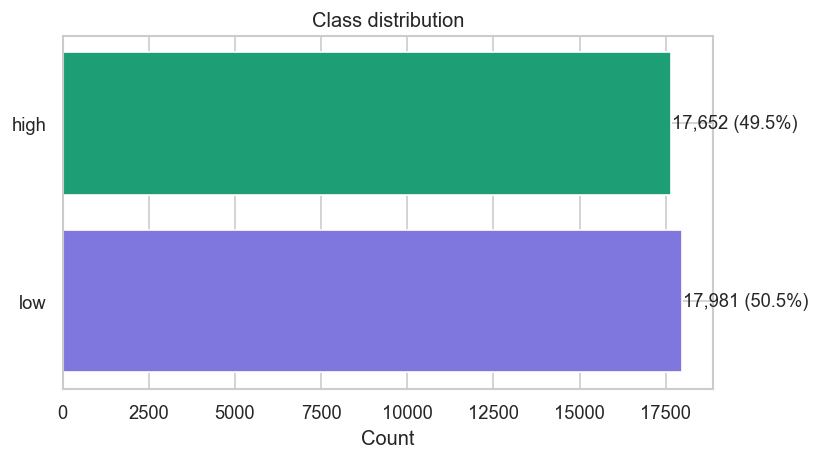

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['label'].value_counts()
bars = ax.barh(counts.index, counts.values, color=['#7F77DD', '#1D9E75', '#D85A30'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=11)
ax.set_xlabel('Count')
ax.set_title('Class distribution')
plt.tight_layout()
plt.savefig('../docs/plot_class_distribution.png', bbox_inches='tight')
plt.show()

# OBSERVATION:
# The dataset is almost perfectly balanced (50.5% low, 49.5% high), so I will first train the baseline model without using SMOTE or class weighting.

## 3. Text length distribution

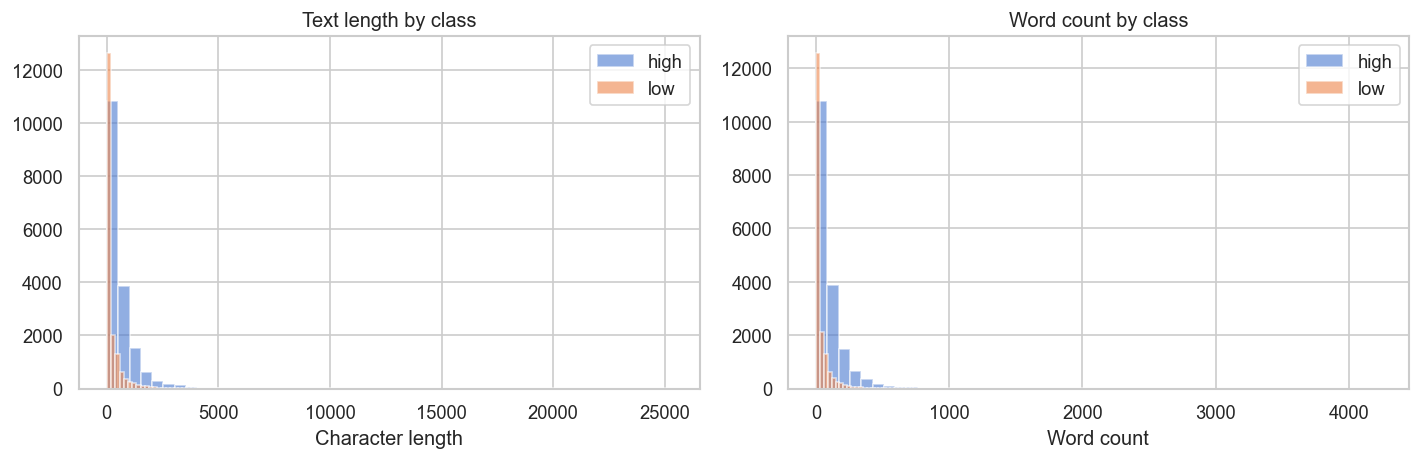

      text_len                                                   word_count  \
         count   mean    std   min    25%    50%    75%      max      count   
label                                                                         
high   17652.0  626.7  846.3  11.0  180.0  376.5  768.0  25289.0    17652.0   
low    17981.0  262.7  449.6  11.0   62.0  107.0  255.0   9410.0    17981.0   

                                                     
        mean    std  min   25%   50%    75%     max  
label                                                
high   105.3  140.8  1.0  30.0  62.0  129.0  4239.0  
low     40.4   64.5  1.0  11.0  18.0   40.0  1462.0  


In [7]:
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby('label'):
    axes[0].hist(grp['text_len'], bins=50, alpha=0.6, label=label)
axes[0].set_xlabel('Character length')
axes[0].set_title('Text length by class')
axes[0].legend()

for label, grp in df.groupby('label'):
    axes[1].hist(grp['word_count'], bins=50, alpha=0.6, label=label)
axes[1].set_xlabel('Word count')
axes[1].set_title('Word count by class')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/plot_text_length.png', bbox_inches='tight')
plt.show()

print(df.groupby('label')[['text_len','word_count']].describe().round(1))

# OBSERVATION:
# High-risk posts are generally longer than low-risk posts. This suggests that users discussing mental health issues tend to provide more detailed context.

## 4. Top tokens per class (TF-IDF)

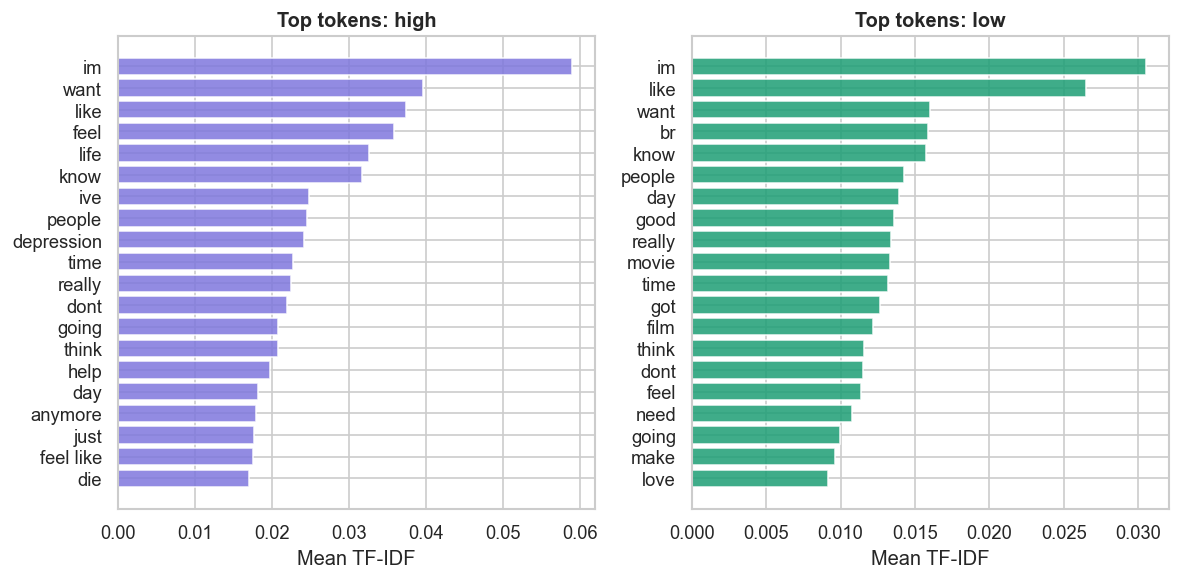

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

labels = df['label'].unique()
fig, axes = plt.subplots(1, len(labels), figsize=(5 * len(labels), 5))
if len(labels) == 1:
    axes = [axes]

colors = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517']

for ax, label, color in zip(axes, labels, colors):
    subset = df[df['label'] == label]['text'].fillna('')
    vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
    tfidf = vec.fit_transform(subset)
    scores = tfidf.mean(axis=0).A1
    top_idx = scores.argsort()[-20:][::-1]
    top_tokens = [vec.get_feature_names_out()[i] for i in top_idx]
    top_scores = [scores[i] for i in top_idx]
    ax.barh(top_tokens[::-1], top_scores[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top tokens: {label}', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')

plt.tight_layout()
plt.savefig('../docs/plot_top_tokens.png', bbox_inches='tight')
plt.show()

# OBSERVATION:
# Words such as "depression", "die", and "help" appear more frequently in high-risk posts, whereas low-risk posts contain more neutral vocabulary like "movie" and "love".

## 5. Null / missing values check

In [9]:
null_report = df.isnull().sum().reset_index()
null_report.columns = ['column', 'null_count']
null_report['pct'] = (null_report['null_count'] / len(df) * 100).round(2)
null_report[null_report['null_count'] > 0].sort_values('pct', ascending=False)

,column,null_count,pct
